# SCC 453 Project - Maaz Adnan

# 1. Imports and Basic Helper Functions

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import torch
from sklearn.metrics import confusion_matrix
from pathlib import Path
os.chdir("/content/drive/MyDrive/453 project")

sns.set_theme(style="whitegrid")

TRAIN_PATH = Path(f"{os.getcwd()}/SemEval_Dataset/subtaskA_train_monolingual.jsonl")
TEST_PATH = Path(f"{os.getcwd()}/SemEval_Dataset/subtaskA_dev_monolingual.jsonl")
random_seed =0

print(f"Train path: {TRAIN_PATH}")
print(f"Test path: {TEST_PATH}")

def load_jsonl(path: Path) -> list[dict]:
    with path.open("r", encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]

Train path: /content/drive/MyDrive/453 project/SemEval_Dataset/subtaskA_train_monolingual.jsonl
Test path: /content/drive/MyDrive/453 project/SemEval_Dataset/subtaskA_dev_monolingual.jsonl


# SemEval8 Task A EDA

This notebook focuses on dataset size and simple summary statistics for the monolingual train and dev splits.

In [13]:
# 1) Load train and dev datasets once
train_records = load_jsonl(TRAIN_PATH)
dev_records = load_jsonl(TEST_PATH)

train_df = pd.DataFrame(train_records)
dev_df = pd.DataFrame(dev_records)
combined_df = pd.concat([train_df, dev_df], ignore_index=True)

print(f"Train rows: {len(train_df):,}")
print(f"Dev rows:   {len(dev_df):,}")
print(f"Total rows: {len(combined_df):,}")
print(f"Columns:    {combined_df.columns.tolist()}")

Train rows: 119,757
Dev rows:   5,000
Total rows: 124,757
Columns:    ['text', 'label', 'model', 'source', 'id']


## 2. Dataset Size and Quick Inspection

In [14]:
# Split sizes and quick sample view
size_df = pd.DataFrame(
    {
        "split": ["train", "dev", "combined"],
        "rows": [len(train_df), len(dev_df), len(combined_df)],
    }
)
display(size_df)
id_col = "id"
unique_ids = combined_df[id_col].nunique(dropna=True)
print(f"Unique IDs in combined data ({id_col}): {unique_ids:,}")
print("\nSample rows from train:")
display(train_df.head(3))

print("Sample rows from dev:")
display(dev_df.head(3))

,split,rows
0,train,119757
1,dev,5000
2,combined,124757


Unique IDs in combined data (id): 119,757

Sample rows from train:


,text,label,model,source,id
0,Forza Motorsport is a popular racing game that...,1,chatGPT,wikihow,0
1,Buying Virtual Console games for your Nintendo...,1,chatGPT,wikihow,1
2,Windows NT 4.0 was a popular operating system ...,1,chatGPT,wikihow,2


Sample rows from dev:


,text,label,model,source,id
0,Giving gifts should always be enjoyable. Howe...,1,bloomz,wikihow,0
1,Yveltal (Japanese: ユベルタル) is one of the main a...,1,bloomz,wikihow,1
2,If you'd rather not annoy others by being rude...,1,bloomz,wikihow,2


## 3. Simple Summary Statistics

In [15]:
# Missing values, schema, and categorical distributions
missing_df = (
    combined_df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda x: (x["missing_count"] / len(combined_df) * 100).round(2))
    .sort_values("missing_count", ascending=False)
)

print("Schema overview:")
display(pd.DataFrame({"column": combined_df.columns, "dtype": combined_df.dtypes.astype(str)}))

print("Missing-value summary:")
display(missing_df)

label_col = 'label'
model_col = 'model'


label_dist = combined_df[label_col].value_counts(dropna=False).rename_axis(label_col).reset_index(name="count")
label_dist["percentage"] = (label_dist["count"] / len(combined_df) * 100).round(2)
print(f"Label distribution using column: {label_col}")
display(label_dist)


model_dist = combined_df[model_col].value_counts(dropna=False).rename_axis(model_col).reset_index(name="count")
model_dist["percentage"] = (model_dist["count"] / len(combined_df) * 100).round(2)
print(f"Model/source distribution using column: {model_col}")
display(model_dist.head(15))


Schema overview:


,column,dtype
text,text,object
label,label,int64
model,model,object
source,source,object
id,id,int64


Missing-value summary:


,missing_count,missing_pct
text,0,0.0
label,0,0.0
model,0,0.0
source,0,0.0
id,0,0.0


Label distribution using column: label


,label,count,percentage
0,0,65851,52.78
1,1,58906,47.22


Model/source distribution using column: model


,model,count,percentage
0,human,65851,52.78
1,davinci,14343,11.50
2,chatGPT,14339,11.49
3,dolly,14046,11.26
4,cohere,13678,10.96
5,bloomz,2500,2.00


In [16]:
# Text-length summary and source-type summary
text_col = 'text'

text_df = combined_df[combined_df[text_col].notna()].copy()
text_df["word_count"] = text_df[text_col].astype(str).str.split().str.len()

summary_stats = text_df["word_count"].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).to_frame().T
summary_stats.index = ["word_count"]
print(f"Text column used: {text_col}")
print("Word-count summary:")
display(summary_stats.round(2))

if model_col:
    machine_mask = (
        text_df[model_col].notna()
        & text_df[model_col].astype(str).str.strip().ne("")
        & ~text_df[model_col].astype(str).str.lower().isin({"human", "none", "nan", "n/a"})
    )
else:
    machine_mask = pd.Series(False, index=text_df.index)

text_df["source_type"] = np.where(machine_mask, "Machine", "Human")

source_summary = (
    text_df.groupby("source_type")["word_count"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
    .sort_index()
)
print("Word-count summary by source type:")
display(source_summary)

Text column used: text
Word-count summary:


,count,mean,std,min,25%,50%,75%,90%,max
word_count,124757.0,456.07,655.44,2.0,200.0,275.0,457.0,872.0,33223.0


Word-count summary by source type:


,count,mean,median,std,min,max
source_type,,,,,,
Human,65851,585.95,296.0,863.42,2,33223
Machine,58906,310.87,262.0,191.13,6,2830


## 4. Simple Visualizations

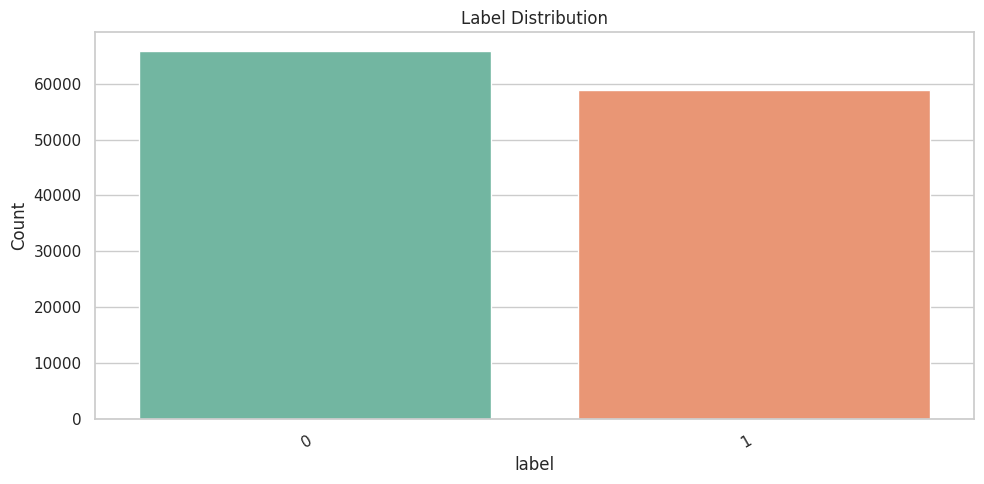

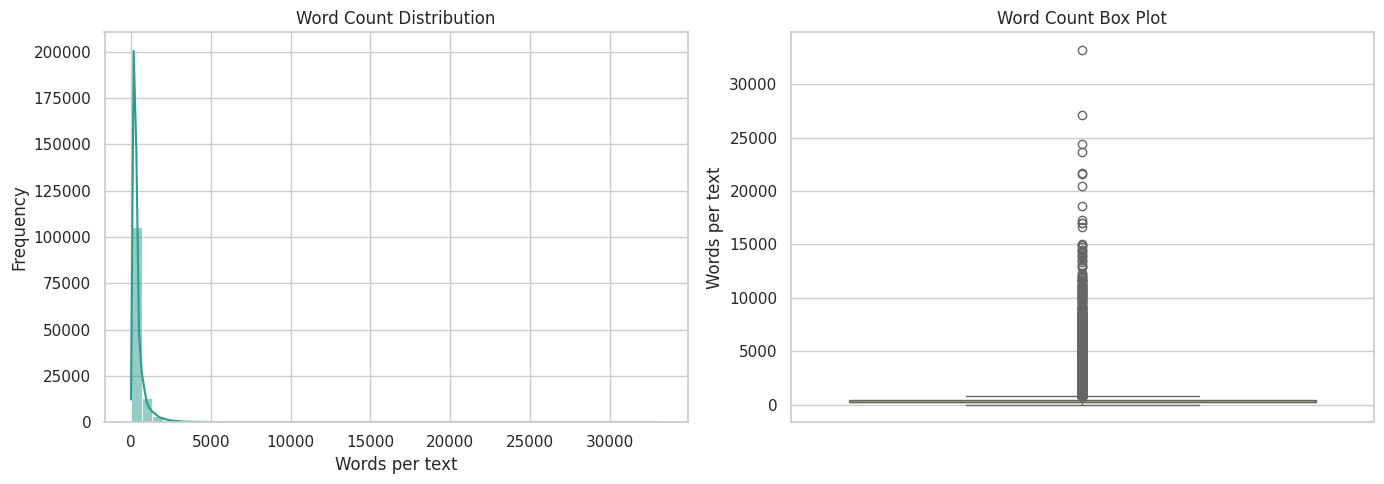

In [17]:
# Plot 1: label distribution (if available)

plt.figure(figsize=(10, 5))
plot_df = label_dist.copy()
sns.barplot(
    data=plot_df,
    x=label_col,
    y="count",
    hue=label_col,
    legend=False,
    palette="Set2",
)
plt.title("Label Distribution")
plt.xlabel(label_col)
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


# Plot 2: word-count distribution + box plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=text_df, x="word_count", bins=50, kde=True, ax=axes[0], color="#2a9d8f")
axes[0].set_title("Word Count Distribution")
axes[0].set_xlabel("Words per text")
axes[0].set_ylabel("Frequency")

sns.boxplot(data=text_df, y="word_count", ax=axes[1], color="#e9c46a")
axes[1].set_title("Word Count Box Plot")
axes[1].set_ylabel("Words per text")

plt.tight_layout()
plt.show()

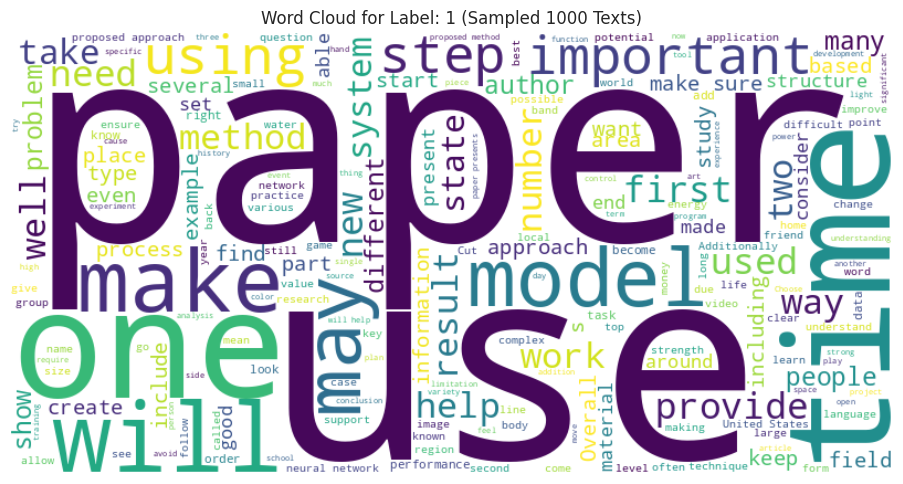

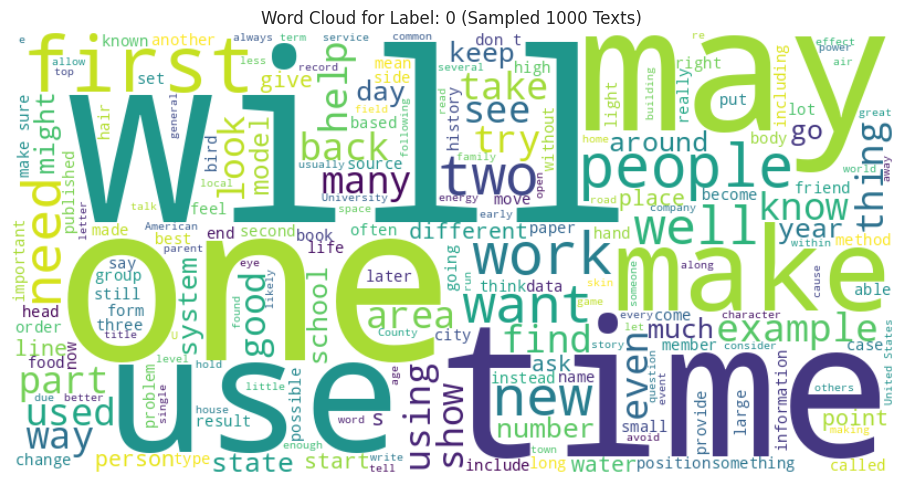

In [18]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import random

unique_labels = train_df['label'].unique()

# Set a random seed for reproducibility of sampling
random_seed = 42
random.seed(random_seed)

for i, label in enumerate(unique_labels):
    # Filter texts for the current label
    filtered_texts = train_df[train_df['label'] == label]['text']

    # Take a random sample of up to 1000 texts
    sample_size = min(len(filtered_texts), 1000)
    if sample_size > 0:
        sampled_texts = filtered_texts.sample(n=sample_size, random_state=random_seed)
        label_texts = sampled_texts.str.cat(sep=' ')
    else:
        label_texts = ""

    if label_texts:
        # Generate word cloud
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(label_texts)

        # Create a new figure for each word cloud
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f'Word Cloud for Label: {label} (Sampled {sample_size} Texts)')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f"No text available for label: {label} to generate a word cloud.")

# FOR ALL Models -> Imports and Helper Functions

In [19]:
!pip install -q -U evaluate

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [21]:
from datasets import Dataset
import pandas as pd
import evaluate
import numpy as np
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, AutoTokenizer, set_seed
import os
from sklearn.model_selection import train_test_split
from scipy.special import softmax
import argparse
import logging
import unicodedata
import torch
import torch.nn as nn
from transformers import AutoModel
from torch.utils.data import DataLoader
from torch.optim import AdamW
import torch.nn.functional as F
from tqdm.auto import tqdm
import json
from pathlib import Path
import numpy as np
import evaluate


In [22]:
def clean_text(text):
    if not isinstance(text, str):
        return text

    cleaned = unicodedata.normalize("NFKD", text.replace("\n", " ").replace("\t", " "))
    cleaned = cleaned.encode("ascii", "ignore").decode("utf-8")
    return " ".join(cleaned.split())

def preprocess_function(examples, **fn_kwargs):
    texts = examples["text"]

    #apply cleaning to each text, whether it's a single string or a batch
    if isinstance(texts, list):
        texts = [clean_text(t) for t in texts]
    else:
        texts = clean_text(texts)
    return fn_kwargs["tokenizer"](texts, truncation=True)

def get_data(train_path, test_path, random_seed):

    train_df = pd.read_json(train_path, lines=True)
    test_df = pd.read_json(test_path, lines=True)

    subset_df, _ = train_test_split(
        train_df,
        test_size=0.40, # We toss 40%, keep 60%
        stratify=train_df[['label','source']],
        random_state=random_seed
    )

    #stratified random sampling but with 50% data, then 80% for train, 20% for validation
    train_df, val_df = train_test_split(
        subset_df,
        test_size=0.20,
        stratify=subset_df[['label', 'source']],
        random_state=random_seed
    )
    print(f"train data size{train_df.shape[0]}")
    print(f"val data size{val_df.shape[0]}")
    print(f"test data size{test_df.shape[0]}")
    return train_df, val_df, test_df

f1_metric = evaluate.load("f1")
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    results = {}
    results.update(f1_metric.compute(predictions=predictions, references = labels, average="micro"))

    return results

def build_label_maps():
    id2label = {0: "human", 1: "machine"}
    label2id = {"human": 0, "machine": 1}
    return id2label, label2id

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


# Model 1 -> Roberta Base

## 1. Define Fine Tune Function

In [23]:
def fine_tune_baseline(train_df, valid_df, checkpoints_path, id2label, label2id, model_name):
    train_dataset = Dataset.from_pandas(train_df)
    valid_dataset = Dataset.from_pandas(valid_df)

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id,
    )

    tokenized_train_dataset = train_dataset.map(
        preprocess_function, batched=True, fn_kwargs={"tokenizer": tokenizer}
    )
    tokenized_valid_dataset = valid_dataset.map(
        preprocess_function, batched=True, fn_kwargs={"tokenizer": tokenizer}
    )

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    training_args = TrainingArguments(
        output_dir=str(checkpoints_path),
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train_dataset,
        eval_dataset=tokenized_valid_dataset,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()

    best_model_path = Path(checkpoints_path) / "best"
    best_model_path.mkdir(parents=True, exist_ok=True)
    trainer.save_model(str(best_model_path))
    return best_model_path

In [24]:
def test(test_df, model_path, id2label, label2id, results_path=None):
    tokenizer = AutoTokenizer.from_pretrained(str(model_path))
    model = AutoModelForSequenceClassification.from_pretrained(
        str(model_path),
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id,
    )

    test_dataset = Dataset.from_pandas(test_df)
    tokenized_test_dataset = test_dataset.map(
        preprocess_function, batched=True, fn_kwargs={"tokenizer": tokenizer}
    )
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    trainer = Trainer(
        model=model,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    predictions = trainer.predict(tokenized_test_dataset)
    _ = softmax(predictions.predictions, axis=-1)
    preds = np.argmax(predictions.predictions, axis=-1)

    metric = evaluate.load("bstrai/classification_report")
    results = metric.compute(predictions=preds, references=predictions.label_ids)

    if results_path is not None:
        results_path = Path(results_path)
        results_path.parent.mkdir(parents=True, exist_ok=True)

        with results_path.open("w", encoding="utf-8") as f:
            json.dump(results, f, indent=2)
        print(f"Evaluation results saved to {results_path}")

        preds_path = results_path.parent / (results_path.stem + "_predictions.jsonl")
        with preds_path.open("w", encoding="utf-8") as f:
            for pred, label in zip(preds.tolist(), predictions.label_ids.tolist()):
                f.write(json.dumps({"prediction": pred, "label": label}) + "\n")
        print(f"Predictions saved to {preds_path}")

    return results, preds

## 2. Training Loop

In [28]:
VALID_MODES = ["train_and_test", "train", "test","continue"]
RUN_PIPELINE = {
    "mode": "test"   # choose one of: "train_and_test", "train", "test"
}
assert RUN_PIPELINE["mode"] in VALID_MODES, f"Invalid mode '{RUN_PIPELINE['mode']}'. Must be one of {VALID_MODES}"


In [29]:
MODEL_NAME = "roberta-base"
checkpoint_dir = Path(f"{os.getcwd()}/final_final/{MODEL_NAME}/checkpoints")
results_path = Path(f"{os.getcwd()}/final_final/{MODEL_NAME}/test_results.json")
print(f"Checkpoint directory: {checkpoint_dir}")
print(f"Mode: {RUN_PIPELINE['mode']}")

Checkpoint directory: /content/drive/MyDrive/453 project/final_final/roberta-base/checkpoints
Mode: test


In [30]:
if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"File doesn't exist: {TRAIN_PATH}")
if not TEST_PATH.exists():
    raise FileNotFoundError(f"File doesn't exist: {TEST_PATH}")

id2label, label2id = build_label_maps()
set_seed(random_seed)
mode = RUN_PIPELINE["mode"]
if mode == "continue":
  pass
elif mode == "train_and_test":
    print(f"--- Step 1: Fine-Tuning Model ({MODEL_NAME}) ---")
    train_df, valid_df, test_df = get_data(TRAIN_PATH, TEST_PATH, random_seed)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    best_model_path = fine_tune_baseline(
        train_df=train_df,
        valid_df=valid_df,
        checkpoints_path=checkpoint_dir,
        id2label=id2label,
        label2id=label2id,
        model_name=MODEL_NAME,
    )
    print(f"Best model saved to: {best_model_path}")

    print(f"--- Step 2: Testing Model ({MODEL_NAME}) ---")
    #defining path of where to save results
    results, preds = test(
        test_df=test_df,
        model_path=best_model_path,
        id2label=id2label,
        label2id=label2id,
        results_path=results_path,
    )
    print(results)

elif mode == "train":
    print(f"--- Step 1: Fine-Tuning Model ({MODEL_NAME}) ---")
    train_df, valid_df, _ = get_data(TRAIN_PATH, TEST_PATH, random_seed)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    best_model_path = fine_tune_baseline(
        train_df=train_df,
        valid_df=valid_df,
        checkpoints_path=checkpoint_dir,
        id2label=id2label,
        label2id=label2id,
        model_name=MODEL_NAME,
    )
    print(f"Best model saved to: {best_model_path}")

elif mode == "test":
    print(f"--- Step 2: Testing Model ({MODEL_NAME}) ---")
    best_model_path = checkpoint_dir / "best"
    if not best_model_path.exists():
        raise FileNotFoundError(
            f"No saved model found for test mode at: {best_model_path}. Run train or train_and_test first."
        )

    test_df = pd.read_json(TEST_PATH, lines=True)
    results, preds = test(
        test_df=test_df,
        model_path=best_model_path,
        id2label=id2label,
        label2id=label2id,
        results_path=results_path,
    )
    print(results)

--- Step 2: Testing Model (roberta-base) ---


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Evaluation results saved to /content/drive/MyDrive/453 project/final_final/roberta-base/test_results.json
Predictions saved to /content/drive/MyDrive/453 project/final_final/roberta-base/test_results_predictions.jsonl
{'0': {'precision': 0.7073482428115015, 'recall': 0.8856, 'f1-score': 0.7865008880994672, 'support': 2500.0}, '1': {'precision': 0.8470588235294118, 'recall': 0.6336, 'f1-score': 0.7249427917620137, 'support': 2500.0}, 'accuracy': 0.7596, 'macro avg': {'precision': 0.7772035331704567, 'recall': 0.7596, 'f1-score': 0.7557218399307404, 'support': 5000.0}, 'weighted avg': {'precision': 0.7772035331704567, 'recall': 0.7596, 'f1-score': 0.7557218399307405, 'support': 5000.0}}


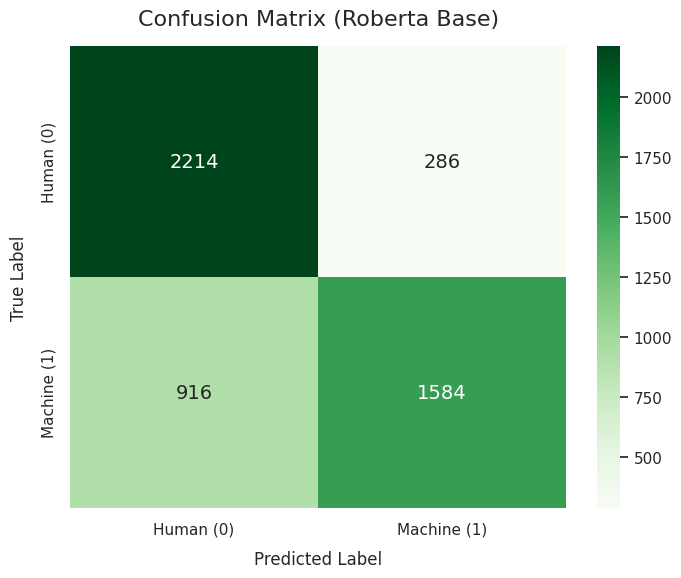

In [31]:
roberta_base_dict = load_jsonl(path=Path("/content/drive/MyDrive/453 project/final_final/roberta-base/test_results_predictions.jsonl"))
roberta_base_df = pd.DataFrame(roberta_base_dict)

y_true_rb = roberta_base_df['label']
y_pred_rb = roberta_base_df['prediction']

cm_distilbert = confusion_matrix(y_true_rb, y_pred_rb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_distilbert, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Human (0)', 'Machine (1)'],
            yticklabels=['Human (0)', 'Machine (1)'],
            annot_kws={"size": 14})

plt.title('Confusion Matrix (Roberta Base)', fontsize=16, pad=15)
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.ylabel('True Label', fontsize=12, labelpad=10)
plt.show()

# Model 2 -> DistilledBert

## we will simply re-run the training since the model name is changed the rest is the same

In [32]:
MODEL_NAME = "distilbert-base-uncased"
checkpoint_dir = Path(f"{os.getcwd()}/final_final/{MODEL_NAME}/checkpoints")
results_path = Path(f"{os.getcwd()}/final_final/{MODEL_NAME}/test_results.json")
print(f"Checkpoint directory: {checkpoint_dir}")
print(f"Mode: {RUN_PIPELINE['mode']}")

Checkpoint directory: /content/drive/MyDrive/453 project/final_final/distilbert-base-uncased/checkpoints
Mode: test


In [33]:
if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"File doesn't exist: {TRAIN_PATH}")
if not TEST_PATH.exists():
    raise FileNotFoundError(f"File doesn't exist: {TEST_PATH}")

id2label, label2id = build_label_maps()
set_seed(random_seed)
mode = RUN_PIPELINE["mode"]
if mode == "continue":
  pass
if mode == "train_and_test":
    print(f"--- Step 1: Fine-Tuning Model ({MODEL_NAME}) ---")
    train_df, valid_df, test_df = get_data(TRAIN_PATH, TEST_PATH, random_seed)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    best_model_path = fine_tune_baseline(
        train_df=train_df,
        valid_df=valid_df,
        checkpoints_path=checkpoint_dir,
        id2label=id2label,
        label2id=label2id,
        model_name=MODEL_NAME,
    )
    print(f"Best model saved to: {best_model_path}")

    print(f"--- Step 2: Testing Model ({MODEL_NAME}) ---")
    #defining path of where to save results
    results, preds = test(
        test_df=test_df,
        model_path=best_model_path,
        id2label=id2label,
        label2id=label2id,
        results_path=results_path,
    )
    print(results)

elif mode == "train":
    print(f"--- Step 1: Fine-Tuning Model ({MODEL_NAME}) ---")
    train_df, valid_df, _ = get_data(TRAIN_PATH, TEST_PATH, random_seed)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    best_model_path = fine_tune_baseline(
        train_df=train_df,
        valid_df=valid_df,
        checkpoints_path=checkpoint_dir,
        id2label=id2label,
        label2id=label2id,
        model_name=MODEL_NAME,
    )
    print(f"Best model saved to: {best_model_path}")

elif mode == "test":
    print(f"--- Step 2: Testing Model ({MODEL_NAME}) ---")
    best_model_path = checkpoint_dir / "best"
    if not best_model_path.exists():
        raise FileNotFoundError(
            f"No saved model found for test mode at: {best_model_path}. Run train or train_and_test first."
        )

    test_df = pd.read_json(TEST_PATH, lines=True)
    results, preds = test(
        test_df=test_df,
        model_path=best_model_path,
        id2label=id2label,
        label2id=label2id,
        results_path=results_path,
    )
    print(results)

--- Step 2: Testing Model (distilbert-base-uncased) ---


Loading weights:   0%|          | 0/104 [00:02<?, ?it/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Evaluation results saved to /content/drive/MyDrive/453 project/final_final/distilbert-base-uncased/test_results.json
Predictions saved to /content/drive/MyDrive/453 project/final_final/distilbert-base-uncased/test_results_predictions.jsonl
{'0': {'precision': 0.7129600989792763, 'recall': 0.922, 'f1-score': 0.8041165184022326, 'support': 2500.0}, '1': {'precision': 0.8896434634974533, 'recall': 0.6288, 'f1-score': 0.7368174361378017, 'support': 2500.0}, 'accuracy': 0.7754, 'macro avg': {'precision': 0.8013017812383647, 'recall': 0.7754000000000001, 'f1-score': 0.7704669772700172, 'support': 5000.0}, 'weighted avg': {'precision': 0.8013017812383647, 'recall': 0.7754, 'f1-score': 0.7704669772700172, 'support': 5000.0}}


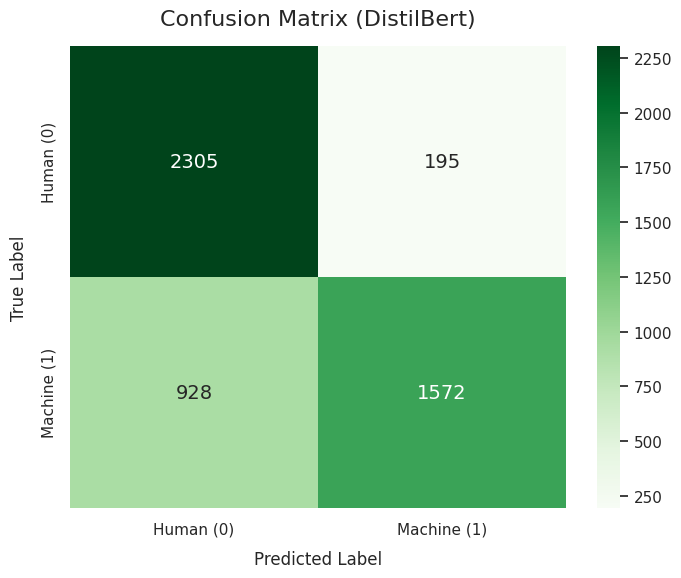

In [34]:
distilbert_basic_list = load_jsonl(path=Path("/content/drive/MyDrive/453 project/final_final/distilbert-base-uncased/test_results_predictions.jsonl"))
distilbert_basic_df = pd.DataFrame(distilbert_basic_list)

y_true_distilbert = distilbert_basic_df['label']
y_pred_distilbert = distilbert_basic_df['prediction']

cm_distilbert = confusion_matrix(y_true_distilbert, y_pred_distilbert)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_distilbert, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Human (0)', 'Machine (1)'],
            yticklabels=['Human (0)', 'Machine (1)'],
            annot_kws={"size": 14})

plt.title('Confusion Matrix (DistilBert)', fontsize=16, pad=15)
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.ylabel('True Label', fontsize=12, labelpad=10)
plt.show()

# Model 3 -> DistilBert + Custom Classifier + Post-Processing

In [35]:
!pip install -q language-tool-python nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 5.6 MB/s eta 0:00:00


## 1. Defining Constants

In [36]:
MODEL_NAME = "distilbert-base-uncased"
checkpoint_dir = Path(f"{os.getcwd()}/final_final/{MODEL_NAME}_custom/checkpoints")
results_path = Path(f"{os.getcwd()}/final_final/{MODEL_NAME}_custom/test_results.json")
#set random seed
random_seed =0

best_model_path = Path(checkpoint_dir) / "best_model.pt"

RUN_PIPELINE = {
    "mode": "train_and_test"   # choose one of: "train_and_test", "train", "test"
}

#Setup Labels based on Subtask
id2label = {0: "human", 1: "machine"}
label2id = {"human": 0, "machine": 1}
print(f"Checkpoint directory: {checkpoint_dir}")
print(f"Mode: {RUN_PIPELINE['mode']}")

Checkpoint directory: /content/drive/MyDrive/453 project/final_final/distilbert-base-uncased_custom/checkpoints
Mode: train_and_test


## Functions to Calculate Statistics

In [37]:
!pip install -q -U textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 115.5 MB/s eta 0:00:00


In [38]:
import textstat
import re

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

nltk.download('punkt_tab')
nltk.download('stopwords')

stop_words_set = set(stopwords.words('english'))

def apply_textual_post_processing(text, predicted_label, confidence, theta = 0.99):

    if predicted_label == 1 and confidence < theta:

        # A. Flesch-Kincaid Grade Level Readability Score (RS)
        rs = textstat.flesch_kincaid_grade(text)
        # Tokenize text to calculate word metrics (ignoring punctuation)
        words = text.split()
        total_words = len(words)

        if total_words == 0:
            return predicted_label

        # Stop Word Score (SWS): Total stop words / total words
        stop_words_in_text = [w for w in words if w in stop_words_set]
        total_stop_words = len(stop_words_in_text)
        sws = total_stop_words / total_words

        # Unique Word Score (UWS): Unique non-stop words / total non-stop words
        non_stop_words = [w for w in words if w not in stop_words_set]
        total_non_stop_words = len(non_stop_words)
        unique_non_stop_words_count = len(set(non_stop_words))

        uws = unique_non_stop_words_count / total_non_stop_words if total_non_stop_words > 0 else 0

        if rs <= 50 and (sws >= 0.35 or uws <= 0.75):
            # Overrule the model and change the prediction to Human
            return 0

    # If the conditions aren't met, return the original prediction
    return predicted_label

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Defining Architecture

In [51]:
class DistilBertCustomClassifier(nn.Module):
    def __init__(self, model_name='distilbert-base-uncased', num_classes=2, dropout_rate=0.2):
        super(DistilBertCustomClassifier, self).__init__()

        # Use AutoModel to get raw hidden states from the backbone.
        self.backbone = AutoModel.from_pretrained(model_name)

        hidden_size = self.backbone.config.hidden_size

        self.dropout1 = nn.Dropout(dropout_rate)
        self.dropout2 = nn.Dropout(dropout_rate)

        self.dense = nn.Linear(hidden_size * 2, 512)
        self.output_layer = nn.Linear(512, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state

        # 1. First Dropout
        x = self.dropout1(sequence_output)

        # 2. Global Pooling with masking
        mask = attention_mask.unsqueeze(-1).expand(x.size()).float()
        masked_x = x * mask

        max_pool = torch.max(x + (1 - mask) * -1e9, dim=1).values

        # Average Pooling (ignoring padding)
        avg_pool = torch.sum(masked_x, dim=1) / torch.clamp(mask.sum(dim=1), min=1e-9)

        # 3. Fusion
        fused = torch.cat((max_pool, avg_pool), dim=1)

        # 4. Dense -> ReLU -> Second Dropout
        dense_out = torch.relu(self.dense(fused))
        dropped_out = self.dropout2(dense_out)

        # 5. Classification logits (return raw logits for CrossEntropyLoss)
        logits = self.output_layer(dropped_out)
        return logits

In [52]:
metric = evaluate.load("bstrai/classification_report")
def evaluate_model(model, dataloader, device,metric = metric, results_path=None):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            # Handle DataCollator renaming 'label' to 'labels'
            labels = batch['labels'].to(device) if 'labels' in batch else batch['label'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    results = metric.compute(predictions=all_preds, references=all_labels)
    avg_loss = total_loss / len(dataloader)

    # Extract macro avg f1-score from the classification report
    f1_score = results.get("macro avg", {}).get("f1-score", 0.0)

    return avg_loss, f1_score, all_preds, all_labels


## Tokenizing Datasets

In [53]:
from datasets import Dataset

def tokenize_datasets(train_df, valid_df,test_df):
    train_dataset = Dataset.from_pandas(train_df)
    valid_dataset = Dataset.from_pandas(valid_df)
    test_dataset = Dataset.from_pandas(test_df)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    tokenized_train_dataset = train_dataset.map(
        preprocess_function, batched=True, fn_kwargs={"tokenizer": tokenizer}
    )
    tokenized_valid_dataset = valid_dataset.map(
        preprocess_function, batched=True, fn_kwargs={"tokenizer": tokenizer}
    )
    tokenized_test_dataset = test_dataset.map(
        preprocess_function, batched=True, fn_kwargs={"tokenizer": tokenizer}
    )
    return tokenized_train_dataset, tokenized_valid_dataset,tokenized_test_dataset


## Training Loop

### Tokenize and Format for Pytorch

In [54]:
# Tokenize and Format Datasets for PyTorch ---
columns_to_return = ['input_ids', 'attention_mask', 'label']
train_df, valid_df, test_df = get_data(TRAIN_PATH, TEST_PATH, random_seed)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoded_train_df, encoded_val_df, encoded_test_df = tokenize_datasets(train_df, valid_df,test_df)

encoded_train_df.set_format(type='torch', columns=columns_to_return)
encoded_val_df.set_format(type='torch', columns=columns_to_return)
encoded_test_df.set_format(type='torch', columns=columns_to_return)


train data size57483
val data size14371
test data size5000


Map:   0%|          | 0/57483 [00:00<?, ? examples/s]

Map:   0%|          | 0/14371 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

### Create DataLoaders and define optimizers

In [55]:
from transformers import DataCollatorWithPadding, AutoTokenizer
# data loaders
BATCH_SIZE = 32

#tokenizer with data collation so its all the same length
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

#loaders
train_dataloader = DataLoader(encoded_train_df, batch_size=BATCH_SIZE, shuffle=True, collate_fn=data_collator)
val_dataloader = DataLoader(encoded_val_df, batch_size=BATCH_SIZE, collate_fn=data_collator)
test_dataloader = DataLoader(encoded_test_df, batch_size=BATCH_SIZE, collate_fn=data_collator)

#Initialize parameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DistilBertCustomClassifier(model_name=MODEL_NAME).to(device)

#define epochs for training loop
EPOCHS = 3
best_val_loss = float('inf')
best_epoch = -1

#make the checkpoint directory
os.makedirs(checkpoint_dir, exist_ok=True)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [56]:
report_metric = evaluate.load("bstrai/classification_report")

VALID_MODES = ["train_and_test", "train", "test"]
RUN_PIPELINE = {
    "mode": "test"   # choose one of: "train_and_test", "train", "test"
}
assert RUN_PIPELINE["mode"] in VALID_MODES, f"Invalid mode '{RUN_PIPELINE['mode']}'"

# initialize optimizer and criterion
optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

mode = RUN_PIPELINE["mode"]

if mode in ["train_and_test", "train"]:
    print(f"Training Custom DistilBert Model")
    best_val_loss = float('inf')

    for epoch in range(EPOCHS):
        model.train()
        total_train_loss = 0

        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        progress_bar = tqdm(train_dataloader, desc="Training")

        for batch in progress_bar:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device) if 'labels' in batch else batch['label'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train_loss += loss.item()
            progress_bar.set_postfix({'loss': loss.item()})

        avg_train_loss = total_train_loss / len(train_dataloader)
        val_loss, val_f1, _, _ = evaluate_model(model, val_dataloader, device)

        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1 (Macro): {val_f1:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            print(f"Validation loss improved. Saving model to {best_model_path}")
            torch.save(model.state_dict(), best_model_path)

if mode in ["train_and_test", "test"]:
    print(f"\n--- Step 2: Testing Custom Model ---")
    if not best_model_path.exists():
        raise FileNotFoundError(f"No saved model found at: {best_model_path}")
    else:
        print(f"Loading best model from {best_model_path}")
    # Load best model
    model.load_state_dict(torch.load(best_model_path))
    model.to(device)

    test_loss, test_f1, test_preds, test_labels = evaluate_model(model, test_dataloader, device)
    print(f"Test Loss: {test_loss:.4f} | Test F1 (Macro): {test_f1:.4f}")

    results = report_metric.compute(predictions=test_preds, references=test_labels)

    # Save results
    with results_path.open("w", encoding="utf-8") as f:
        json.dump(results, f, indent=2)
    print(f"Evaluation results saved to {results_path}")

    # Save predictions
    prediction_path = Path(checkpoint_dir) / "predictions.jsonl"
    with Path(prediction_path).open("w", encoding="utf-8") as f:
        for pred, label in zip(test_preds, test_labels):
            f.write(json.dumps({"prediction": int(pred), "label": int(label)}) + "\n")
    print(f"Predictions saved to {prediction_path}")
    print(json.dumps(results, indent=2))


--- Step 2: Testing Custom Model ---
Loading best model from /content/drive/MyDrive/453 project/final_final/distilbert-base-uncased_custom/checkpoints/best_model.pt
Test Loss: 1.2498 | Test F1 (Macro): 0.7092
Evaluation results saved to /content/drive/MyDrive/453 project/final_final/distilbert-base-uncased_custom/test_results.json
Predictions saved to /content/drive/MyDrive/453 project/final_final/distilbert-base-uncased_custom/checkpoints/predictions.jsonl
{
  "0": {
    "precision": 0.6553357481192533,
    "recall": 0.9408,
    "f1-score": 0.7725406470684841,
    "support": 2500.0
  },
  "1": {
    "precision": 0.8951098511693835,
    "recall": 0.5052,
    "f1-score": 0.6458706213244695,
    "support": 2500.0
  },
  "accuracy": 0.723,
  "macro avg": {
    "precision": 0.7752227996443184,
    "recall": 0.723,
    "f1-score": 0.7092056341964768,
    "support": 5000.0
  },
  "weighted avg": {
    "precision": 0.7752227996443185,
    "recall": 0.723,
    "f1-score": 0.7092056341964768,


### Adding DistilBert Post Processing

In [57]:
model = DistilBertCustomClassifier(model_name=MODEL_NAME).to(device)
model.load_state_dict(torch.load(best_model_path))
model.eval()
all_probabilities = []
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_dataloader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device) if 'labels' in batch else batch['label'].to(device)

        logits = model(input_ids, attention_mask)
        probabilities = torch.softmax(logits, dim=-1)
        preds = torch.argmax(logits, dim=-1)
        probs = torch.softmax(logits, dim=-1)

        all_probabilities.extend(probabilities.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_dataloader.dataset.reset_format()
# Create a DataFrame to display predictions and probabilities
predictions_df = pd.DataFrame({
    'id': test_dataloader.dataset['id'],
    'text': test_dataloader.dataset['text'],
    'True Label': all_labels,
    'Predicted Label': all_preds,
    'Probability Human': [p[0] for p in all_probabilities],
    'Probability Machine': [p[1] for p in all_probabilities]
})

print("Sample of Test Predictions with Probabilities:")
display(predictions_df.head())


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/157 [00:00<?, ?it/s]

Sample of Test Predictions with Probabilities:


,id,text,True Label,Predicted Label,Probability Human,Probability Machine
0,0,Giving gifts should always be enjoyable. Howe...,1,1,0.030497,0.969503
1,1,Yveltal (Japanese: ユベルタル) is one of the main a...,1,0,0.753485,0.246515
2,2,If you'd rather not annoy others by being rude...,1,1,0.018243,0.981757
3,3,If you're interested in visiting gravesite(s) ...,1,0,0.807158,0.192842
4,4,The following are some tips for becoming succe...,1,1,0.003991,0.996009


### Original Dataset Confusion Matrix

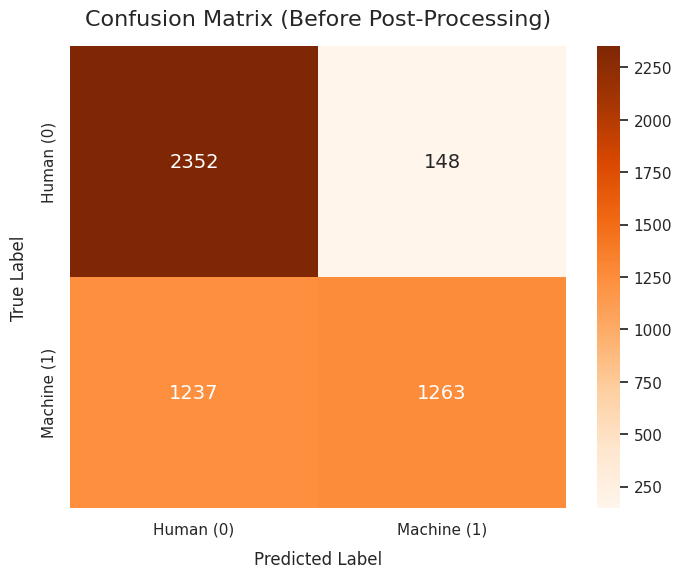

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


cm_old = confusion_matrix(predictions_df['True Label'],predictions_df['Predicted Label'])


plt.figure(figsize=(8, 6))


sns.heatmap(cm_old, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Human (0)', 'Machine (1)'],
            yticklabels=['Human (0)', 'Machine (1)'],
            annot_kws={"size": 14})

# 4. Add titles and labels
plt.title('Confusion Matrix (Before Post-Processing)', fontsize=16, pad=15)
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.ylabel('True Label', fontsize=12, labelpad=10)

# 5. Display the plot
plt.show()


In [46]:
#just in case
predictions_df_orig = predictions_df.copy()

In [59]:
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, classification_report

tqdm.pandas()

thetas = [0.5, 0.6, 0.7, 0.8, 0.95, 0.99]

y_true = predictions_df['True Label']
y_pred_old = predictions_df['Predicted Label']
acc_old = accuracy_score(y_true, y_pred_old)

print(f"Baseline Original Accuracy: {acc_old:.4f} ({acc_old * 100:.2f}%)\n")
print("-" * 30)

for i in thetas:
    predictions_df['Post_Processed_Label'] = predictions_df.progress_apply(
        lambda row: apply_textual_post_processing(
            text=row['text'],
            predicted_label=row['Predicted Label'],
            confidence=row['Probability Machine'],
            theta=i
        ), axis=1
    )

    y_pred_new = predictions_df['Post_Processed_Label']
    changed_rows = predictions_df[predictions_df['Predicted Label'] != y_pred_new]

    print(f"\nResults for Theta: {i}")
    print(f"Labels changed: {len(changed_rows)}")

    if not changed_rows.empty:
        display(changed_rows[['text', 'True Label', 'Predicted Label', 'Post_Processed_Label', 'Probability Machine']].head())

    acc_new = accuracy_score(y_true, y_pred_new)
    print(f"Post-Processed Accuracy: {acc_new:.4f} ({acc_new * 100:.2f}%)")

    print(f"Classification Report (Theta {i}):")
    print(classification_report(y_true, y_pred_new, target_names=['Human (0)', 'Machine (1)']))
    print("=" * 50)

Baseline Original Accuracy: 0.7230 (72.30%)

------------------------------


  0%|          | 0/5000 [00:00<?, ?it/s]


Results for Theta: 0.5
Labels changed: 0
Post-Processed Accuracy: 0.7230 (72.30%)
Classification Report (Theta 0.5):
              precision    recall  f1-score   support

   Human (0)       0.66      0.94      0.77      2500
 Machine (1)       0.90      0.51      0.65      2500

    accuracy                           0.72      5000
   macro avg       0.78      0.72      0.71      5000
weighted avg       0.78      0.72      0.71      5000



  0%|          | 0/5000 [00:00<?, ?it/s]


Results for Theta: 0.6
Labels changed: 6


...

Post-Processed Accuracy: 0.7224 (72.24%)
Classification Report (Theta 0.95):
              precision    recall  f1-score   support

   Human (0)       0.65      0.95      0.77      2500
 Machine (1)       0.91      0.49      0.64      2500

    accuracy                           0.72      5000
   macro avg       0.78      0.72      0.71      5000
weighted avg       0.78      0.72      0.71      5000



  0%|          | 0/5000 [00:00<?, ?it/s]


Results for Theta: 0.99
Labels changed: 86


,text,True Label,Predicted Label,Post_Processed_Label,Probability Machine
0,Giving gifts should always be enjoyable. Howe...,1,1,0,0.969503
16,You may have been invited by one of your frien...,1,1,0,0.827590
19,The next step will be creating an artistic pat...,1,1,0,0.970298
24,This section will show how to fix an issue wit...,1,1,0,0.972487
48,The following is a list of things you should c...,1,1,0,0.989553


Post-Processed Accuracy: 0.7198 (71.98%)
Classification Report (Theta 0.99):
              precision    recall  f1-score   support

   Human (0)       0.65      0.95      0.77      2500
 Machine (1)       0.91      0.48      0.63      2500

    accuracy                           0.72      5000
   macro avg       0.78      0.72      0.70      5000
weighted avg       0.78      0.72      0.70      5000



In [60]:
from sklearn.metrics import accuracy_score, classification_report

y_true = predictions_df['True Label']
y_pred_old = predictions_df['Predicted Label']
y_pred_new = predictions_df['Post_Processed_Label']

acc_old = accuracy_score(y_true, y_pred_old)
acc_new = accuracy_score(y_true, y_pred_new)
print(f"Original Accuracy: {acc_old:.4f} ({acc_old * 100:.2f}%)")
print(f"Final Accuracy (After Post-Processing): {acc_new:.4f} ({acc_new * 100:.2f}%)\n")

print("Classification Report (After Post-Processing):")
print(classification_report(y_true, y_pred_new, target_names=['Human (0)', 'Machine (1)']))


Original Accuracy: 0.7230 (72.30%)
Final Accuracy (After Post-Processing): 0.7198 (71.98%)

Classification Report (After Post-Processing):
              precision    recall  f1-score   support

   Human (0)       0.65      0.95      0.77      2500
 Machine (1)       0.91      0.48      0.63      2500

    accuracy                           0.72      5000
   macro avg       0.78      0.72      0.70      5000
weighted avg       0.78      0.72      0.70      5000



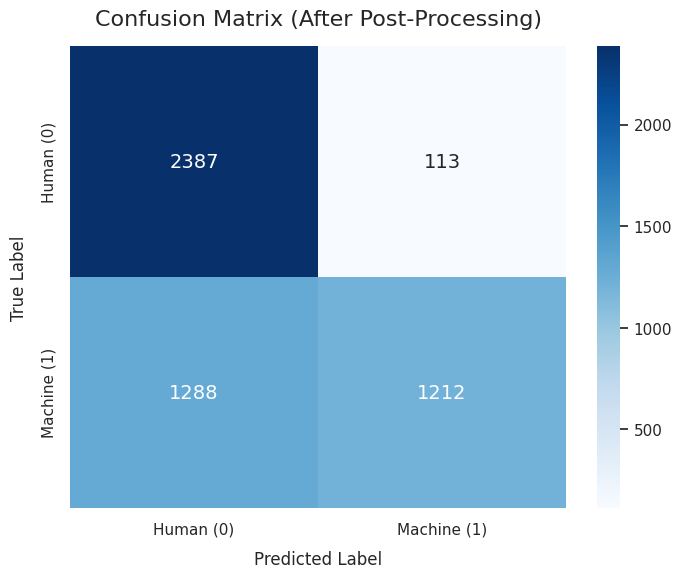

In [61]:
cm = confusion_matrix(y_true, y_pred_new)

plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human (0)', 'Machine (1)'],
            yticklabels=['Human (0)', 'Machine (1)'],
            annot_kws={"size": 14})

plt.title('Confusion Matrix (After Post-Processing)', fontsize=16, pad=15)
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.ylabel('True Label', fontsize=12, labelpad=10)

plt.show()
